In [60]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

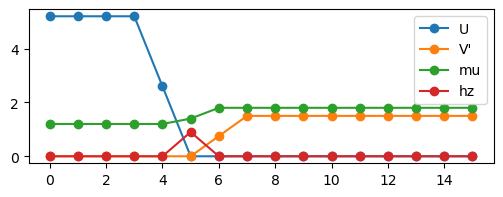

In [61]:
widthS = 5
widthF = 1
widthP = 10

X, Y = widthS+widthF+widthP, 100
lattice = Lattice(X, Y)

t = 1
T = 2.5

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS + widthF] = muF
mu[widthS + widthF:] = muP

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthS:widthS + widthF] = h0

V = None

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthS] = 0
V_prime[widthF+widthS] = V_prime0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

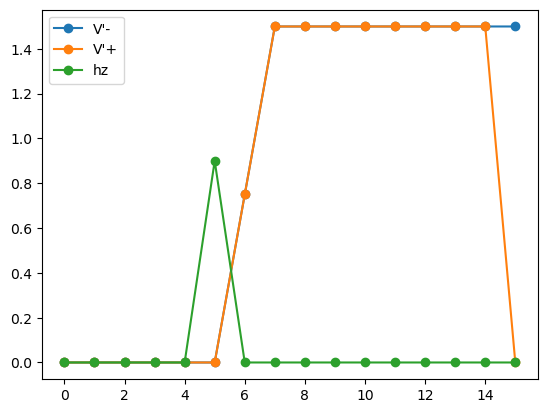

In [62]:
# V_plus = np.r_[V[:-1], [0]]
# V_minus = np.r_[[0], V[1:]]
Vprime_plus = np.r_[V_prime[:-1], [0]]
Vprime_minus = np.r_[[0], V_prime[1:]]

plt.plot(Vprime_minus, "-o", label="V'-")
plt.plot(Vprime_plus, "-o", label="V'+")
# plt.plot(V_minus, "-o", label="V-")
# plt.plot(V_plus, "-o", label="V+")
plt.plot(h, '-o', label='hz')
plt.legend()

In [63]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F0_init=0.5,
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hy=h)

In [64]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=100, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.2751072115994236
Relative error: 2830307089.892406
Average old: (0.15625+0j)
Average: (0.12881207651765345+9.182140228987259e-06j)
F_xplus:
Absolute error: 0.02020025386197722
Relative error: 20200253861.97722
Average old: 0j
Average: (-0.002877710412247044-3.4077716225128153e-06j)
F_xmin:
Absolute error: 0.020200354014694322
Relative error: 20200354014.69432
Average old: 0j
Average: (-0.002877727204109153-4.576092612436266e-06j)
F_yplus:
Absolute error: 0.0267759884467808
Relative error: 26775988446.7808
Average old: 0j
Average: (-0.0036837683088073087-1.0729120069617702e-06j)
F_ymin:
Absolute error: 0.02677598844678078
Relative error: 26775988446.780777
Average old: 0j
Average: (-0.0036837683088073066-1.0729120071376936e-06j)
Fuu_xplus:
Absolute error: 0.21864179873193518
Relative error: 7453753401.617063
Average old: (0.06+0j)
Average: (0.016800804485921462-0.0001579786526402144j)
Fuu_xmin:
Absolute error: 0.23736517575156865
Relative error: 2295122851.77814
Av

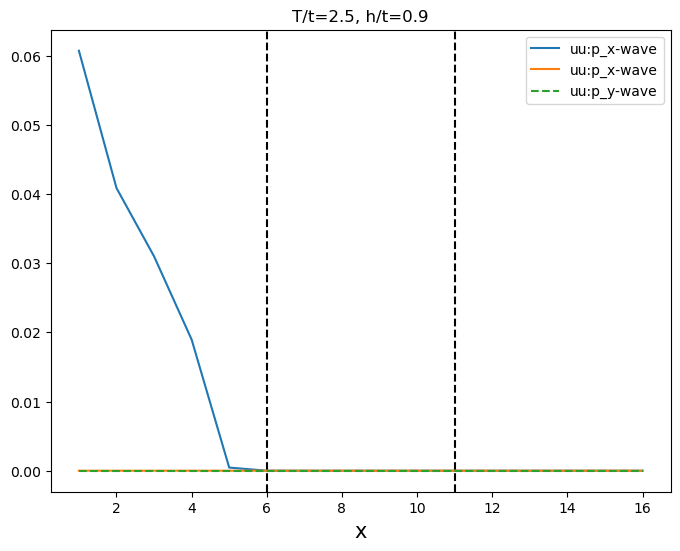

In [65]:
x = np.arange(1, widthS + widthF + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, h/t={h0}")
axs.axvline(int(widthS+widthF+widthP/2), color='black', linestyle='--')
axs.axvline(widthS+widthF, color='black', linestyle='--')
# axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
# axs.plot(x, np.imag(F.dwave), label="Im(F.dwave)")
# axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
# axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(H.F0), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.legend()
plt.show()

In [66]:
print(H.converged)

False


In [67]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.30 + 1e-12, 0.01),
    np.arange(0.31, 0.60 + 1e-12, 0.002)
])
print(len(temps))

185


In [68]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.30 + 1e-12, 0.01),
    np.arange(0.31, 0.41 + 1e-12, 0.001),
    np.arange(0.42, 0.60 + 1e-12, 0.002)
])  # 231 temps total
print(len(temps))

231
